In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [3]:
def read_calibration(calib_file):
    """
    Reads f (focal length) and B (baseline) from KITTI calibration files.
    """
    with open(calib_file, 'r') as f:
        lines = f.readlines()
        
    P2 = None
    P3 = None
    
    for line in lines:
        # Standard KITTI
        if line.startswith('P2:'):
            P2 = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)
        if line.startswith('P3:'):
            P3 = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)
        # Raw KITTI (calib_cam_to_cam)
        if line.startswith('P_rect_02:'):
            P2 = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)
        if line.startswith('P_rect_03:'):
            P3 = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)
            
    if P2 is None or P3 is None:
        return 721.5, 0.54 # Defaults

    f = P2[0, 0]
    B = np.abs(P2[0, 3] - P3[0, 3]) / f
    return f, B

In [4]:
def compute_stereo_match(img_left, img_right, method='SAD', window_size=7, max_disp=128):
    h, w = img_left.shape
    
    # Initialize costs
    if method == 'NCC':
        best_cost = np.full((h, w), -1.0, dtype=np.float32)
    else:
        best_cost = np.full((h, w), np.inf, dtype=np.float32)
        
    best_disp = np.zeros((h, w), dtype=np.float32)
    
    # Pre-compute squares for NCC
    if method == 'NCC':
        l_sq = img_left ** 2
        r_sq = img_right ** 2
        l_sum_sq = cv2.boxFilter(l_sq, -1, (window_size, window_size), normalize=False)

    # Loop over disparity range
    for d in range(max_disp):
        if d > 0:
            shifted_r = np.pad(img_right, ((0,0), (d,0)), mode='constant')[:, :-d]
            if method == 'NCC':
                shifted_r_sq = np.pad(r_sq, ((0,0), (d,0)), mode='constant')[:, :-d]
        else:
            shifted_r = img_right
            if method == 'NCC':
                shifted_r_sq = r_sq

        # --- Calculate Cost ---
        if method == 'SAD':
            diff = np.abs(img_left - shifted_r)
            cost = cv2.boxFilter(diff, -1, (window_size, window_size), normalize=False)
            
            mask = cost < best_cost
            best_cost[mask] = cost[mask]
            best_disp[mask] = d

        elif method == 'SSD':
            diff = (img_left - shifted_r) ** 2
            cost = cv2.boxFilter(diff, -1, (window_size, window_size), normalize=False)
            
            mask = cost < best_cost
            best_cost[mask] = cost[mask]
            best_disp[mask] = d

        elif method == 'NCC':
            product = img_left * shifted_r
            num = cv2.boxFilter(product, -1, (window_size, window_size), normalize=False)
            
            r_sum_sq = cv2.boxFilter(shifted_r_sq, -1, (window_size, window_size), normalize=False)
            denom = np.sqrt(l_sum_sq * r_sum_sq) + 1e-10
            ncc = num / denom
            
            mask = ncc > best_cost
            best_cost[mask] = ncc[mask]
            best_disp[mask] = d

    return best_disp

In [5]:
def compute_lr_disparity(imgL, imgR, method, window_size, max_disp):
    # Left->Right
    disp_L = compute_stereo_match(imgL, imgR, method, window_size, max_disp)
    
    # Right->Left (Flip Trick)
    imgL_flip = cv2.flip(imgL, 1)
    imgR_flip = cv2.flip(imgR, 1)
    disp_flip = compute_stereo_match(imgR_flip, imgL_flip, method, window_size, max_disp)
    disp_R = cv2.flip(disp_flip, 1)
    
    return disp_L, disp_R

In [6]:
def apply_consistency_and_fill(disp_L, disp_R, threshold=1.0):
    h, w = disp_L.shape
    Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    
    X_R = X - disp_L
    X_R_int = X_R.astype(int)
    
    valid_mask = (X_R_int >= 0) & (X_R_int < w)
    
    disp_R_sampled = np.zeros_like(disp_L)
    disp_R_sampled[valid_mask] = disp_R[Y[valid_mask], X_R_int[valid_mask]]
    
    diff = np.abs(disp_L - disp_R_sampled)
    consistent_mask = valid_mask & (diff <= threshold)
    
    disp_filtered = np.zeros_like(disp_L)
    disp_filtered[consistent_mask] = disp_L[consistent_mask]
    
    # Fill Holes
    invalid_mask = (disp_filtered == 0).astype(np.uint8)
    disp_filled = cv2.inpaint(disp_filtered.astype(np.float32), invalid_mask, 3, cv2.INPAINT_TELEA)
    
    return disp_filled

In [7]:
def evaluate_disparity(estimated_disp, gt_path, threshold=3.0):
    if not os.path.exists(gt_path):
        return None, None, None

    # Load GT (16-bit PNG)
    gt_img = cv2.imread(gt_path, cv2.IMREAD_UNCHANGED)
    gt_disp = gt_img.astype(np.float32) / 256.0
    
    # Valid Mask (GT > 0)
    valid_mask = (gt_disp > 0)
    
    # Crop to match sizes if needed
    h, w = estimated_disp.shape
    gt_disp = gt_disp[:h, :w]
    valid_mask = valid_mask[:h, :w]
    
    # Calculate Error
    abs_diff = np.abs(estimated_disp - gt_disp)
    valid_errors = abs_diff[valid_mask]
    
    # Metrics
    mae = np.mean(valid_errors)
    bad_pixels = np.count_nonzero(valid_errors > threshold)
    total_valid = np.count_nonzero(valid_mask)
    bad_pixel_rate = (bad_pixels / total_valid) * 100.0
    
    # Error Map
    error_map = np.zeros_like(estimated_disp)
    error_map[valid_mask] = abs_diff[valid_mask]
    
    return mae, bad_pixel_rate, error_map


Calibration: f=721.54, B=0.53

Starting comparison for Image 000001...
------------------------------------------------------------

>>> Processing Method: SAD
   1. Computing Block Matching...
   2. Applying Consistency Check & Filling Holes...
   3. Evaluating...
   [RESULTS] SAD
   MAE:       7.1567 px
   Bad Pixel: 35.46 %


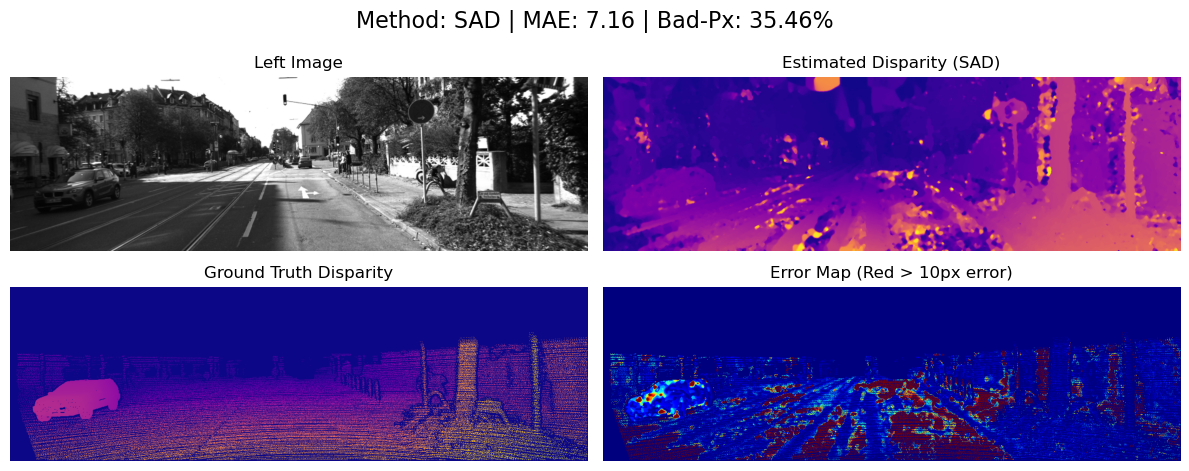


>>> Processing Method: SSD
   1. Computing Block Matching...
   2. Applying Consistency Check & Filling Holes...
   3. Evaluating...
   [RESULTS] SSD
   MAE:       6.5805 px
   Bad Pixel: 33.28 %


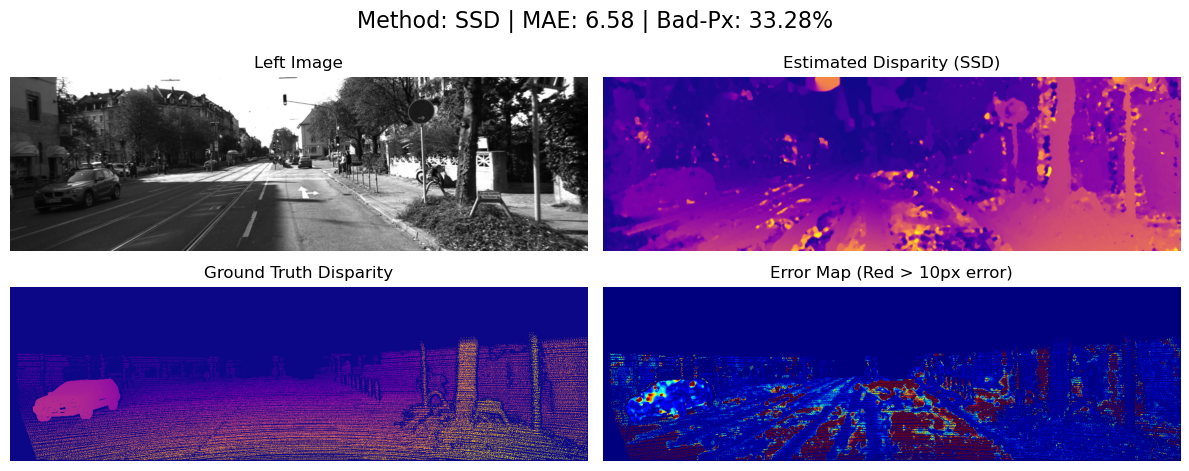


>>> Processing Method: NCC
   1. Computing Block Matching...
   2. Applying Consistency Check & Filling Holes...
   3. Evaluating...
   [RESULTS] NCC
   MAE:       2.7639 px
   Bad Pixel: 16.25 %


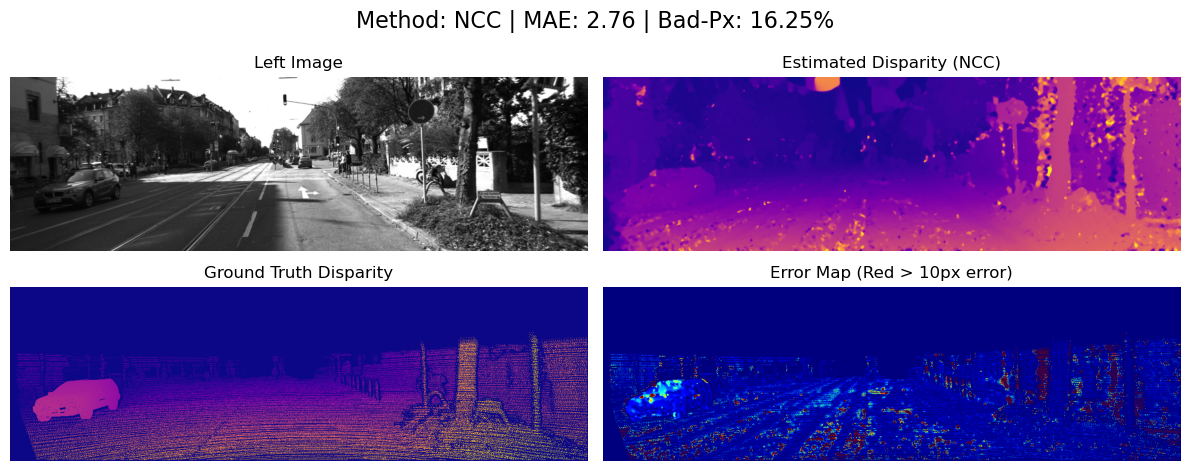

In [8]:
# --- PATHS ---
base_dir = "data/stereo/training/" 
img_idx = "000001" 

left_img_path = os.path.join(base_dir, "image_2", f"{img_idx}_10.png")
right_img_path = os.path.join(base_dir, "image_3", f"{img_idx}_10.png")
calib_path = os.path.join(base_dir, "calib_cam_to_cam", f"{img_idx}.txt") 
gt_path = os.path.join(base_dir, "disp_noc_0", f"{img_idx}_10.png")

# 1. Load Data Once
if not os.path.exists(left_img_path):
    print("Error: Images not found.")
else:
    imgL = cv2.imread(left_img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    imgR = cv2.imread(right_img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

    if os.path.exists(calib_path):
        f, B = read_calibration(calib_path)
        print(f"Calibration: f={f:.2f}, B={B:.2f}")
    else:
        f, B = 721.5, 0.54
        print("Using Default Calibration.")

    # 2. Define Methods to Run
    methods = ['SAD', 'SSD', 'NCC']
    
    print(f"\nStarting comparison for Image {img_idx}...")
    print("-" * 60)

    # 3. Loop Through Methods
    for method in methods:
        print(f"\n>>> Processing Method: {method}")
        
        # A. Compute Raw Disparities
        print("   1. Computing Block Matching...")
        raw_disp_L, raw_disp_R = compute_lr_disparity(imgL, imgR, method=method, window_size=7, max_disp=128)
        
        # B. Consistency & Hole Filling
        print("   2. Applying Consistency Check & Filling Holes...")
        disp_final = apply_consistency_and_fill(raw_disp_L, raw_disp_R)
        
        # C. Median Filter
        disp_final = cv2.medianBlur(disp_final.astype(np.float32), 5)

        # D. Evaluation
        print("   3. Evaluating...")
        mae, bad_px, error_map = evaluate_disparity(disp_final, gt_path, threshold=3.0)

        # E. Print Stats
        if mae is not None:
            print(f"   [RESULTS] {method}")
            print(f"   MAE:       {mae:.4f} px")
            print(f"   Bad Pixel: {bad_px:.2f} %")
        
        # F. Visualization
        plt.figure(figsize=(12, 5))
        plt.suptitle(f"Method: {method} | MAE: {mae:.2f} | Bad-Px: {bad_px:.2f}%", fontsize=16)

        # 1. Left Image
        plt.subplot(2, 2, 1)
        plt.imshow(imgL, cmap='gray')
        plt.title("Left Image")
        plt.axis('off')

        # 2. Estimated Disparity
        plt.subplot(2, 2, 2)
        plt.imshow(disp_final, cmap='plasma')
        plt.title(f"Estimated Disparity ({method})")
        plt.axis('off')

        # 3. Ground Truth
        if mae is not None:
            gt_viz = cv2.imread(gt_path, -1) / 256.0
            plt.subplot(2, 2, 3)
            plt.imshow(gt_viz, cmap='plasma')
            plt.title("Ground Truth Disparity")
            plt.axis('off')

            # 4. Error Map
            plt.subplot(2, 2, 4)
            plt.imshow(error_map, cmap='jet', vmin=0, vmax=10) 
            plt.title("Error Map (Red > 10px error)")
            plt.axis('off')

        plt.tight_layout()
        plt.savefig(f"figures/result_{method}.png")
        plt.show()